# Examining and Visualizing Data

[Pandas](https://pandas.pydata.org/docs/) is a Python library used for data analysis and manipulation. Within the world of data science, it is a ubiquitous and widely used library. If you are learning how to analyze data in Python, it will be almost impossible to avoid pandas.

The central data structure of pandas is called a DataFrame. Pandas DataFrames work very closely with NumPy arrays and Pandas dataframes are specifically for data which is two dimensional (rows and columns). NumPy arrays, while similar in some ways, can work with higher dimensional data.

Pandas is very powerful. In this session, we'll be learning how to access information in pandas dataframes and how to do some basic manipulation and analysis. We are going to be looking at a dataset which gives information about the elements in the periodic table.

In [1]:
%%capture
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    !pip install pandas mols2grid seaborn rdkit matplotlib useful_rdkit_utils scikit-learn ipywidgets

In [2]:
import pandas as pd
import mols2grid
import seaborn as sns
import numpy as np
from rdkit import Chem
from rdkit.Chem import rdFMCS
from rdkit.Chem.Scaffolds.MurckoScaffold import GetScaffoldForMol
import useful_rdkit_utils as uru
from IPython.core.display import HTML

In [4]:
# 1. Install and import the upload utility
from google.colab import files
import pandas as pd

# 2. Upload the file via Colab's upload widget
uploaded = files.upload()  # this prompts you to select a file

# 3. Read the CSV into a DataFrame
#    'uploaded' is a dict mapping filename to bytes, so pick the key
filename = next(iter(uploaded))
df = pd.read_csv(filename)

Saving merged_unique_molecules.csv to merged_unique_molecules.csv


In [5]:
# 4. Display the DataFrame
df

,IDNUMBER,Chemical_Name,CAS,PriceCoeff,MW,Description,FSP3,clogP,TPSA,H-acceptors,...,Activity_value,Activity_units,Target_name,Organism,PPDS,smiles,Collection,Target,Docking_score,LCTNUMBER
0,F2147-9803,1-(1-benzylpiperidin-4-yl)-3-methylimidazolidi...,72338-84-2,1.5,273.37,solid,0.56,0.00,26.79,1,...,3100.0,nM,Dipeptidyl peptidase II,Homo sapiens,+,CN1CCN(C2CCN(CC3=CC=CC=C3)CC2)C1=O,NaN,NaN,NaN,NaN
1,F6541-1489,"1-cyclopropyl-3-(1,2,3,4-tetrahydroisoquinolin...",2097865-50-2,1.5,256.34,oil,0.56,2.34,23.55,1,...,550.0,nM,Prolyl endopeptidase,Homo sapiens,NaN,O=C1C(N2CCC3=C(C=CC=C3)C2)CCN1C1CC1,NaN,NaN,NaN,NaN
2,F1739-0011,"4,6-dimethyl-2-(pyrrolidin-1-yl)pyridine-3-car...",693254-24-9,1.5,201.27,solid,0.50,0.00,39.92,2,...,3548.1,nM,ATP-dependent Clp protease proteolytic subunit,Bacillus subtilis (strain 168),+,CC1=CC(C)=NC(N2CCCC2)=C1C#N,NaN,NaN,NaN,NaN
3,F3162-0106,"6,8-dimethyl-[1,2,4]triazolo[4,3-b]pyridazine",18591-75-8,1.5,148.17,solid,0.29,0.00,43.08,3,...,7943.3,nM,ATP-dependent Clp protease proteolytic subunit,Bacillus subtilis (strain 168),+,CC1=CC(C)=NN2C=NN=C12,NaN,NaN,NaN,NaN
4,F3260-0021,"7-ethyl-3-methyl-8-(4-methylpiperidin-1-yl)-2,...",941873-43-4,1.5,291.35,solid,0.64,0.00,70.47,3,...,200.0,nM,Dipeptidyl peptidase IV,Homo sapiens,+,CCN1C(N2CCC(C)CC2)=NC2=C1C(=O)NC(=O)N2C,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10525,F3398-4952,2-{[6-methyl-2-(pyrrolidin-1-yl)pyrimidin-4-yl...,1031962-03-4,1.0,380.36,solid,0.39,4.10,67.35,4,...,NaN,NaN,NaN,NaN,NaN,CC1=NC(N2CCCC2)=NC(OCC(=O)NC2=CC=CC(C(F)(F)F)=...,General,Elastase,-5.0036,NaN
10526,F6416-5521,N-[3-(1-benzofuran-2-yl)-3-hydroxypropyl]-1-me...,1448054-61-2,1.0,326.35,oil,0.22,1.04,82.78,4,...,NaN,NaN,NaN,NaN,NaN,CN1C=CC=C(C(=O)NCCC(O)C2=CC3=C(C=CC=C3)O2)C1=O,General,Elastase,-5.0031,LCT08840
10527,F6190-1425,N-[3-(furan-2-yl)-3-hydroxypropyl]-N'-[4-methy...,1421476-67-6,1.0,385.41,solid,0.35,0.64,111.88,5,...,NaN,NaN,NaN,NaN,NaN,CC1=C(N2CCCC2=O)C=C(NC(=O)C(=O)NCCC(O)C2=CC=CO...,General,Elastase,-5.0010,LCT08840
10528,F6414-3609,N-[2-(1-benzothiophen-2-yl)-2-hydroxypropyl]-2...,2034547-43-6,1.0,345.84,solid,0.17,3.38,77.57,2,...,NaN,NaN,NaN,NaN,NaN,CC(O)(CNC(=O)C1=C(Cl)C=CC=C1)C1=CC2=C(C=CC=C2)S1,General,Elastase,-5.0010,LCT00381


## Examining Data

In [6]:
# The .head command will display the first five rows of the dataframe.

df.head()

# In Google CoLab, you can click the variable record on the left {x} to learn more about this dataframe.

,IDNUMBER,Chemical_Name,CAS,PriceCoeff,MW,Description,FSP3,clogP,TPSA,H-acceptors,...,Activity_value,Activity_units,Target_name,Organism,PPDS,smiles,Collection,Target,Docking_score,LCTNUMBER
0,F2147-9803,1-(1-benzylpiperidin-4-yl)-3-methylimidazolidi...,72338-84-2,1.5,273.37,solid,0.56,0.00,26.79,1,...,3100.0,nM,Dipeptidyl peptidase II,Homo sapiens,+,CN1CCN(C2CCN(CC3=CC=CC=C3)CC2)C1=O,NaN,NaN,NaN,NaN
1,F6541-1489,"1-cyclopropyl-3-(1,2,3,4-tetrahydroisoquinolin...",2097865-50-2,1.5,256.34,oil,0.56,2.34,23.55,1,...,550.0,nM,Prolyl endopeptidase,Homo sapiens,NaN,O=C1C(N2CCC3=C(C=CC=C3)C2)CCN1C1CC1,NaN,NaN,NaN,NaN
2,F1739-0011,"4,6-dimethyl-2-(pyrrolidin-1-yl)pyridine-3-car...",693254-24-9,1.5,201.27,solid,0.50,0.00,39.92,2,...,3548.1,nM,ATP-dependent Clp protease proteolytic subunit,Bacillus subtilis (strain 168),+,CC1=CC(C)=NC(N2CCCC2)=C1C#N,NaN,NaN,NaN,NaN
3,F3162-0106,"6,8-dimethyl-[1,2,4]triazolo[4,3-b]pyridazine",18591-75-8,1.5,148.17,solid,0.29,0.00,43.08,3,...,7943.3,nM,ATP-dependent Clp protease proteolytic subunit,Bacillus subtilis (strain 168),+,CC1=CC(C)=NN2C=NN=C12,NaN,NaN,NaN,NaN
4,F3260-0021,"7-ethyl-3-methyl-8-(4-methylpiperidin-1-yl)-2,...",941873-43-4,1.5,291.35,solid,0.64,0.00,70.47,3,...,200.0,nM,Dipeptidyl peptidase IV,Homo sapiens,+,CCN1C(N2CCC(C)CC2)=NC2=C1C(=O)NC(=O)N2C,NaN,NaN,NaN,NaN


The `.info` function will give information about the columns and the data type of those columns. The data type will become very important later as we work with data more.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10530 entries, 0 to 10529
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   IDNUMBER        10530 non-null  object 
 1   Chemical_Name   10530 non-null  object 
 2   CAS             10304 non-null  object 
 3   PriceCoeff      10530 non-null  float64
 4   MW              10530 non-null  float64
 5   Description     10530 non-null  object 
 6   FSP3            10530 non-null  float64
 7   clogP           10530 non-null  float64
 8   TPSA            10530 non-null  float64
 9   H-acceptors     10530 non-null  int64  
 10  H-donors        10530 non-null  int64  
 11  RotBonds        10530 non-null  int64  
 12  HAC             10530 non-null  int64  
 13  Similarity      4470 non-null   float64
 14  fromRegid       4470 non-null   object 
 15  Activity_type   4470 non-null   object 
 16  Activity_value  4470 non-null   float64
 17  Activity_units  4470 non-null  

The describe function can be used on a dataframe to quickly see statistics about columns with numerical data. If you look at the columns that statistics are computed for and compare to the data type shown from info, you will see that we only get statistics for columns which had int64 or float64 data types.

In [8]:
df.describe()

,PriceCoeff,MW,FSP3,clogP,TPSA,H-acceptors,H-donors,RotBonds,HAC,Similarity,Activity_value,Docking_score
count,10530.000000,10530.000000,10530.000000,10530.000000,10530.000000,10530.000000,10530.000000,10530.000000,10530.000000,4470.000000,4470.000000,4536.000000
mean,1.063390,400.809519,0.301435,6.912449,88.853464,4.197816,1.946059,5.884615,28.529630,0.892069,4228.832937,-7.826098
std,0.171571,89.546629,0.165017,12.248928,31.321069,1.483469,1.150444,2.447333,6.281394,0.033831,3233.926617,1.183201
min,1.000000,148.160000,0.000000,-11.420000,3.240000,0.000000,0.000000,0.000000,11.000000,0.850000,1.000000,-11.721900
25%,1.000000,347.465000,0.180000,0.530000,67.802500,3.000000,1.000000,4.000000,25.000000,0.860000,2511.900000,-8.641025
50%,1.000000,397.470000,0.280000,2.830000,82.940000,4.000000,2.000000,6.000000,28.000000,0.880000,3900.000000,-8.070650
75%,1.000000,444.480000,0.400000,4.690000,106.207500,5.000000,3.000000,7.000000,32.000000,0.910000,7079.500000,-7.216600
max,5.500000,838.990000,1.000000,59.000000,244.990000,12.000000,8.000000,20.000000,59.000000,1.000000,10000.000000,-5.000300


This information is extremely useful for understanding the data. We can also easily visualize the distribution of each column using Pandas's ``hist`` function.

array([[<Axes: title={'center': 'PriceCoeff'}>,
        <Axes: title={'center': 'MW'}>, <Axes: title={'center': 'FSP3'}>],
       [<Axes: title={'center': 'clogP'}>,
        <Axes: title={'center': 'TPSA'}>,
        <Axes: title={'center': 'H-acceptors'}>],
       [<Axes: title={'center': 'H-donors'}>,
        <Axes: title={'center': 'RotBonds'}>,
        <Axes: title={'center': 'HAC'}>],
       [<Axes: title={'center': 'Similarity'}>,
        <Axes: title={'center': 'Activity_value'}>,
        <Axes: title={'center': 'Docking_score'}>]], dtype=object)

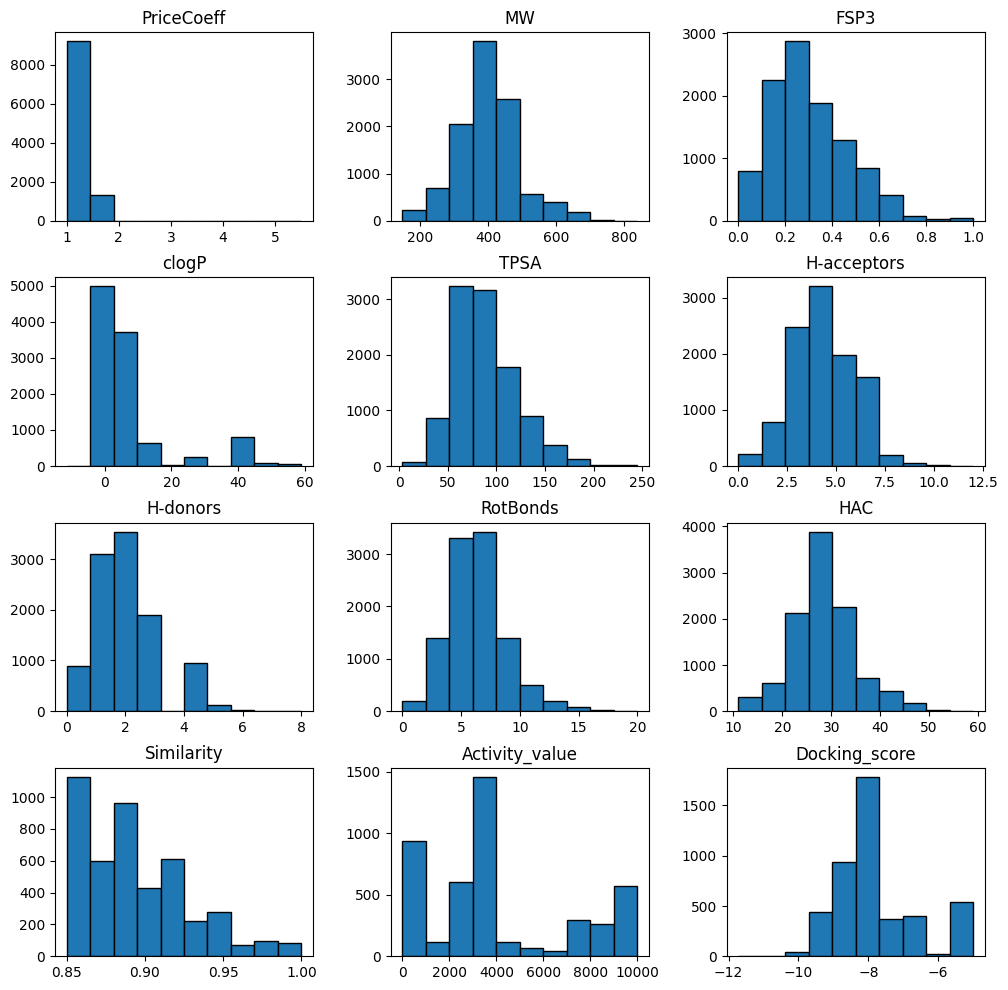

In [9]:
df.hist(figsize=(12, 12), edgecolor="black", grid=False)

## Using RDKit Functions with Pandas DataFrames
For an example more related to our work with RDKit, let's add some additional atomic data.
RDKit has the ability to get information about atoms.
We can create a periodic table with `Chem.GetPeriodicTable`, then use associated functions to get information about atoms to add more information to our existing pandas dataframe.

In [12]:
mols2grid.display(df, smiles_col="smiles",subset=["img","Activity_type","Activity_value"])

MolGridWidget()

In [15]:
# Pivot the table: each activity type becomes a column
pivot_df = df.pivot_table(index='smiles',
                          columns='Activity_type',
                          values='Activity_value',
                          aggfunc='first').reset_index()

In [18]:
print(pivot_df)

Activity_type                                             smiles  AC50  \
0                                      C(#CC1=CC=CC=C1)CN1CCOCC1   NaN   
1                  C/C(Cl)=C/CN1C(N(C)C)=NC2=C1C(=O)N(C)C(=O)N2C   NaN   
2              C/C(Cl)=C/CN1C(N(C)CC2=CC=CC=C2)=NC2=C1C(=O)N(...   NaN   
3               C/C(Cl)=C/CN1C(N2CCC(C)CC2)=NC2=C1C(=O)NC(=O)N2C   NaN   
4              C/C(Cl)=C/CN1C(N2CCC(CC3=CC=CC=C3)CC2)=NC2=C1C...   NaN   
...                                                          ...   ...   
4465           O=S(=O)(NC1=CC(C2=CN3C=CC=NC3=N2)=CC=C1)C1=CC=...   NaN   
4466           O=S(=O)(NC1=CC(C2=CN3C=CC=NC3=N2)=CC=C1)C1=CC=...   NaN   
4467           O=S(=O)(NC1=CC=C(C2=CN3C=CC=CC3=N2)C=C1)C1=CC=...   NaN   
4468           O=S(=O)(NC1=CC=C(C2=CN3C=CC=NC3=N2)C=C1)C1=CC=...   NaN   
4469           O=S(=O)(NC1=CC=C(C2=NC3=C(C=CC=C3)S2)C=C1)C1=C...   NaN   

Activity_type  Activity  EC50   IC50  IC50, Potency  Inhibition  Kd  Ki  \
0                   NaN   NaN    NaN

## Visualizing the Activity Distribution
First, let's set some reasonable defaults for plots.

In [13]:
sns.set(rc={'figure.figsize': (5,5 )})
sns.set_style('whitegrid')
sns.set_context('notebook')

Let's look at the the IC50 distribution for the compounds.  As we can see below, the default view isn't very helpful.

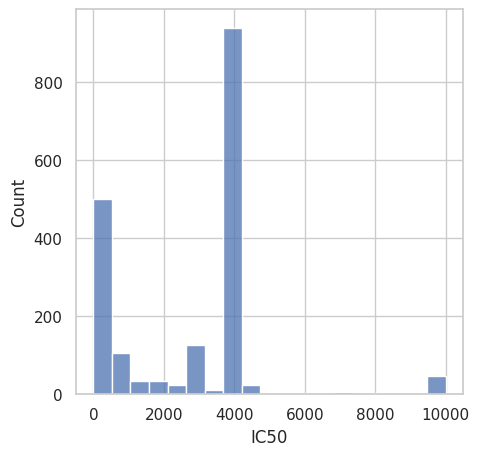

In [20]:
ax = sns.histplot(pivot_df["IC50"])

Similarly you can explore different activity values.

It's oftent easier to look at the distribution of **pIC50** values, where pIC50 is the negative log of the IC50.

In [21]:
pivot_df["pIC50"] = -np.log10(pivot_df["IC50"] * 1e-9)

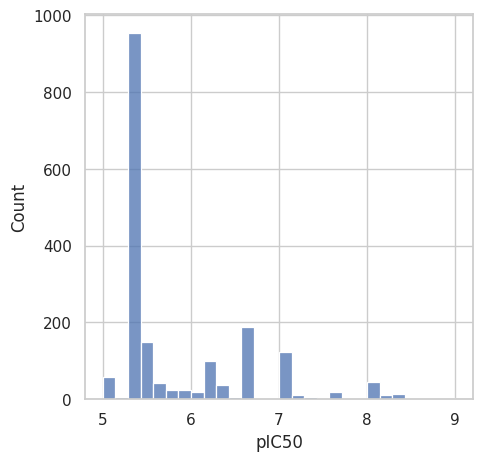

In [22]:
ax = sns.histplot(pivot_df.pIC50)

For visualization it's often helpful to bin the activity into high, medium, and low bins.  Here well put compounds with 6 < pIC50 < 7 (0.1-1$\mu$M) into the "medium" bin, and compounds with pIC50 > 7 into the "high" bin.

In [27]:
pivot_df["activity"] = pd.cut(pivot_df.pIC50,bins=[0,6,7,100],labels=["low","med","high"],right=False)

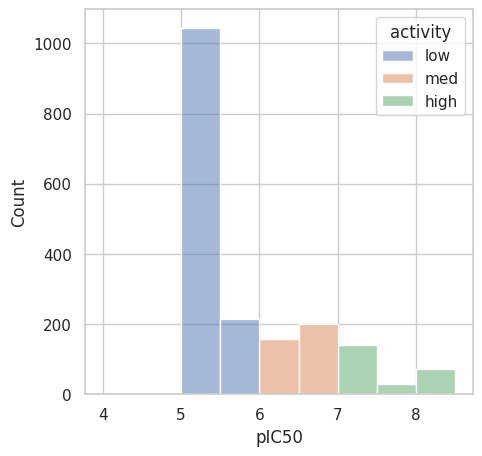

In [28]:
ax = sns.histplot(x="pIC50",hue="activity",data=pivot_df,bins=np.arange(4,9,0.5))

Now that we have the IC50 data binned into high, med, low, we can use these categories to make plots showing mulitple parameters.  Try to make a scatterplot of molecular weight (MW) vs LogP, a measure of lipophilicity.

### Understanding the Chemistry in the Downloaded Molecules
As a first step in this analysis, we will see which parts are common to all of the molecules.  To do this, we can use the Maxiumum Common Substructure (MCS) capability in the RDKit.  To use this capability, we must first convert the SMILES in our dataframe to RDKit molecule objects.  As above, we can use the Pandas apply method to do this.

In [29]:
df['mol'] = df["smiles"].apply(Chem.MolFromSmiles)

In [30]:
mcs = rdFMCS.FindMCS(df.mol)

To visualize the MCS, we have to convert it to an RDKit molecule object.

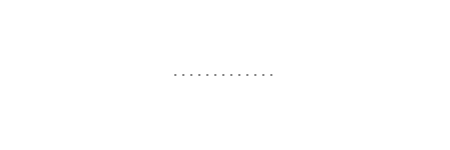

In [31]:
pat = Chem.MolFromSmarts(mcs.smartsString)
pat

The visualization above can be difficult to interpret.  The MCS tends to make more sense when we map it onto the molecules. Here we can map the MCS on to the first molecule in the dataframe and display it as a red highlight. Note how we use the utilitiy function [rd_set_image_size](https://useful-rdkit-utils.readthedocs.io/en/latest/jupyter.html#useful_rdkit_utils.jupyter_utils.rd_set_image_size) from [useful_rdkit_utils](https://useful-rdkit-utils.readthedocs.io/en/latest/index.html) to set the image size.

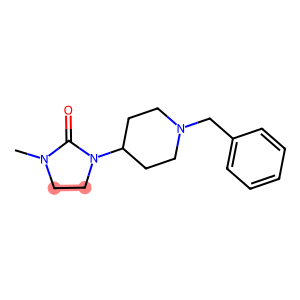

In [32]:
uru.rd_set_image_size(300,300)
df.mol.values[0].GetSubstructMatch(pat)
df.mol.values[0]

Another tool for exploring chemical datasets is the Bemis-Murcko scaffold. In this technique a molecule is reduced to a set of connected rings and linkers.  We can use the **GetScaffoldForMol**  method from the RDKit to generate Bemis-Murcko scaffolds.  

In [33]:
df['Scaffold'] = df.mol.apply(GetScaffoldForMol)

The generated scaffolds are RDKit molecule objects.  We would like to find the most frequently occuring scaffolds.  To do this, we need to convert the scaffolds to SMILES.  

In [34]:
df['Scaffold_SMILES'] = df.Scaffold.apply(Chem.MolToSmiles)

Now we can use the [value_counts_df](https://useful-rdkit-utils.readthedocs.io/en/latest/pandas.html#useful_rdkit_utils.pandas_utils.value_counts_df) method in [useful_rdkit_utils](https://useful-rdkit-utils.readthedocs.io/en/latest/index.html) count how many times each scaffold is used.  

In [35]:
scaffold_counts_df = uru.value_counts_df(df,"Scaffold_SMILES")
scaffold_counts_df.head()

,Scaffold_SMILES,count
0,O=C1/C(=C/c2ccccc2)Oc2ccccc21,259
1,O=c1[nH]c(=O)c2c(nc(N3CCNCC3)n2Cc2ccccc2)[nH]1,158
2,O=c1[nH]c(=O)c2[nH]c(N3CCN(Cc4ccccc4)CC3)nc2[nH]1,150
3,O=c1[nH]c(=O)c2c(ncn2Cc2ccccc2)[nH]1,128
4,O=c1[nH]c(=O)c2[nH]cnc2[nH]1,126


Use the **scaffold_counts_df** we created above to view the scaffolds and their frequencies.

In [36]:
mols2grid.display(scaffold_counts_df,smiles_col="Scaffold_SMILES",subset=["img","count"],size=(250,250),
                  n_items_per_page=6)

MolGridWidget()